<a href="https://colab.research.google.com/github/RagaSandhiya05/LLM-From-Scratch/blob/main/10_Transformer_Block.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TRANSFORMER BLOCK**

**Import Libraries**

In [17]:
import torch
import torch.nn as nn
torch.manual_seed(42)
print("PyTorch Version : " , torch.__version__)

PyTorch Version :  2.11.0+cpu


**Sample Embeddings**

In [18]:
tokens = ["I", "love", "Python"]
embeddings = torch.tensor([
    [1.0, 0.5, 0.2, 0.1] ,
    [0.8, 1.0, 0.4, 0.3] ,
    [0.2, 0.1, 1.0, 0.9]
])
print("Input Embeddings :\n")
print(embeddings)

Input Embeddings :

tensor([[1.0000, 0.5000, 0.2000, 0.1000],
        [0.8000, 1.0000, 0.4000, 0.3000],
        [0.2000, 0.1000, 1.0000, 0.9000]])


**Feed-Forward Network**

In [19]:
embedding_dim = embeddings.shape[1]
ffn = nn.Sequential(
    nn.Linear(embedding_dim , embedding_dim * 2) ,
    nn.ReLU() ,
    nn.Linear(embedding_dim * 2 , embedding_dim)
)

ffn_output = ffn(embeddings)

print("Feed-Forward Output :\n")
print(ffn_output)

Feed-Forward Output :

tensor([[ 0.7750, -0.3702, -0.3981, -0.3978],
        [ 0.7404, -0.2643, -0.4323, -0.4257],
        [ 0.5869, -0.2703, -0.3984, -0.2995]], grad_fn=<AddmmBackward0>)


**Residual Connection**

In [20]:
residual_output = embeddings + ffn_output

print("Residual Connection Output :\n")
print(residual_output)

Residual Connection Output :

tensor([[ 1.7750,  0.1298, -0.1981, -0.2978],
        [ 1.5404,  0.7357, -0.0323, -0.1257],
        [ 0.7869, -0.1703,  0.6016,  0.6005]], grad_fn=<AddBackward0>)


**Layer Normalization**

In [21]:
layer_norm = nn.LayerNorm(embedding_dim)
normalized_output = layer_norm(residual_output)

print("After Layer Normalization :\n")
print(normalized_output)

After Layer Normalization :

tensor([[ 1.7008, -0.2659, -0.6578, -0.7770],
        [ 1.5030,  0.3065, -0.8353, -0.9742],
        [ 0.9010, -1.6949,  0.3985,  0.3954]],
       grad_fn=<NativeLayerNormBackward0>)


**Create Transformer Block**

In [22]:
class TransformerBlock(nn.Module) :
    def __init__(self, embedding_dim) :
        super().__init__()
        self.ffn = nn.Sequential(
            nn.Linear(embedding_dim , embedding_dim * 2) ,
            nn.ReLU() ,
            nn.Linear(embedding_dim * 2 , embedding_dim)
        )
        self.norm = nn.LayerNorm(embedding_dim)

    def forward(self, x) :
        ffn_output = self.ffn(x)
        x = x + ffn_output
        x = self.norm(x)
        return x

**Run Transformer Block**

In [23]:
block = TransformerBlock(embedding_dim)
output = block(embeddings)

print("Transformer Block Output :\n")
print(output)

Transformer Block Output :

tensor([[ 1.7051, -0.2897, -0.7668, -0.6486],
        [ 1.3295,  0.6033, -0.9579, -0.9749],
        [-0.1464, -1.5699,  1.0012,  0.7151]],
       grad_fn=<NativeLayerNormBackward0>)


**Compare Input and Output**

In [24]:
for token , before , after in zip(tokens , embeddings , output) :
    print("=" * 45)

    print("Token :" , token)

    print("\nInput :")
    print(before)

    print("\nOutput :")
    print(after)

Token : I

Input :
tensor([1.0000, 0.5000, 0.2000, 0.1000])

Output :
tensor([ 1.7051, -0.2897, -0.7668, -0.6486], grad_fn=<UnbindBackward0>)
Token : love

Input :
tensor([0.8000, 1.0000, 0.4000, 0.3000])

Output :
tensor([ 1.3295,  0.6033, -0.9579, -0.9749], grad_fn=<UnbindBackward0>)
Token : Python

Input :
tensor([0.2000, 0.1000, 1.0000, 0.9000])

Output :
tensor([-0.1464, -1.5699,  1.0012,  0.7151], grad_fn=<UnbindBackward0>)


**Shape Verification**

In [25]:
print("Input Shape :" , embeddings.shape)

print("Output Shape :" , output.shape)

Input Shape : torch.Size([3, 4])
Output Shape : torch.Size([3, 4])


**Verify Mean and Standard Deviation**

In [26]:
print("Mean of each token :")

print(output.mean(dim = 1))

print("\nStandard Deviation of each token :")

print(output.std(dim = 1 , unbiased = False))

Mean of each token :
tensor([ 5.9605e-08,  5.9605e-08, -5.9605e-08], grad_fn=<MeanBackward1>)

Standard Deviation of each token :
tensor([1.0000, 1.0000, 1.0000], grad_fn=<StdBackward0>)


**Heatmap of Transformer Output**

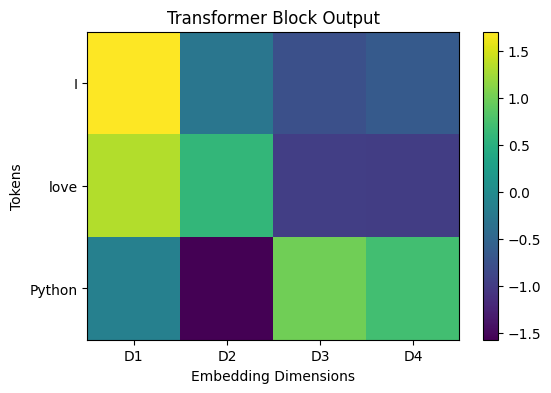

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize = (6 ,4))
plt.imshow(output.detach().numpy() , aspect = "auto")
plt.colorbar()
plt.xticks(range(4) , ["D1" , "D2" , "D3" , "D4"])
plt.yticks(range(3) , tokens)
plt.title("Transformer Block Output")
plt.xlabel("Embedding Dimensions")
plt.ylabel("Tokens")

plt.show()